# Índice meteorológico compuesto de peligro de incendio

Este notebook combina las variables meteorológicas presentes en `firms_spain_final.csv` en un **índice relativo de 0 a 100**. Se usan temperatura, humedad relativa, viento, precipitación, déficit de presión de vapor (VPD) y humedad del suelo.

## Interpretación y límites

Es un índice exploratorio construido para este archivo, **no es el Fire Weather Index (FWI) oficial ni una predicción validada**. Las variables se convierten en percentiles dentro de las filas del CSV; por ello, el resultado indica posición relativa frente a las observaciones de este conjunto, no un nivel absoluto de peligro. Además, el CSV contiene localizaciones con detecciones de incendios, así que no representa todas las condiciones meteorológicas de España. No debe usarse por sí solo para alertas ni decisiones operativas.

Las ponderaciones iniciales son explícitas y editables: temperatura 20%, humedad relativa 20%, viento 20%, precipitación 15%, VPD 15% y humedad del suelo 10%. Los valores altos de temperatura, viento y VPD elevan el score; valores altos de humedad relativa, precipitación y humedad del suelo lo reducen. Se requiere un mínimo de cuatro componentes disponibles por fila; el score ponderado se ajusta a los componentes presentes.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path.home() / 'Desktop' / 'wildfires-project-development' / 'data' / 'processed' / 'enriched' / 'firms_spain_final.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontró el CSV: {csv_path}')

df = pd.read_csv(csv_path, low_memory=False)
required = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Faltan variables necesarias: {missing}')
for col in required:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'{len(df):,} observaciones')
print('Periodo:', df['acq_date'].min(), 'a', df['acq_date'].max())
df[required].describe().T

35,284 observaciones
Periodo: 2023-01-01 a 2024-12-31


,count,mean,std,min,25%,50%,75%,max
temperature_2m,35284.0,17.584621,8.105620,-4.316667,11.531625,16.645000,22.798750,42.565832
relative_humidity_2m,35284.0,53.657755,22.599180,3.331267,35.812815,52.863038,70.905733,100.000000
wind_speed_10m,35284.0,11.320324,7.223642,0.024000,5.957555,9.432533,15.361825,49.461017
precipitation,35284.0,0.017261,0.235227,0.000000,0.000000,0.000000,0.000000,11.500000
vapour_pressure_deficit,35284.0,1.230555,1.191802,0.000000,0.407623,0.804656,1.684952,7.606591
soil_moisture_0_to_7cm,35284.0,0.216008,0.112022,-0.000500,0.124000,0.195350,0.319100,0.513600


## Construcción del score

Cada variable se transforma a percentil empírico entre 0 y 1. Para humedad relativa, precipitación y humedad del suelo se invierte el percentil porque valores altos reducen el peligro meteorológico. La precipitación es la medición disponible en la fecha de la observación; el archivo no aporta una serie diaria completa para calcular acumulados antecedentes fiables.

In [2]:
# peso y sentido del efecto en el peligro (True = un valor alto aumenta el score)
components = {
    'temperature_2m': {'weight': 0.20, 'higher_is_riskier': True},
    'relative_humidity_2m': {'weight': 0.20, 'higher_is_riskier': False},
    'wind_speed_10m': {'weight': 0.20, 'higher_is_riskier': True},
    'precipitation': {'weight': 0.15, 'higher_is_riskier': False},
    'vapour_pressure_deficit': {'weight': 0.15, 'higher_is_riskier': True},
    'soil_moisture_0_to_7cm': {'weight': 0.10, 'higher_is_riskier': False},
}
assert np.isclose(sum(v['weight'] for v in components.values()), 1.0)

risk_subscores = pd.DataFrame(index=df.index)
for col, spec in components.items():
    percentile = df[col].rank(method='average', pct=True)
    risk_subscores[col + '_risk_pct'] = percentile if spec['higher_is_riskier'] else 1 - percentile

weights = pd.Series({col + '_risk_pct': spec['weight'] for col, spec in components.items()})
available_weight = risk_subscores.notna().mul(weights).sum(axis=1)
weighted_score = risk_subscores.mul(weights, axis='columns').sum(axis=1, min_count=1) / available_weight
components_available = risk_subscores.notna().sum(axis=1)
df['indice_meteorologico'] = (weighted_score * 100).where(components_available >= 4)
df['componentes_disponibles'] = components_available
df['nivel_relativo'] = pd.cut(df['indice_meteorologico'], bins=[-0.001, 100/3, 200/3, 100], labels=['Bajo', 'Medio', 'Alto'], include_lowest=True)

print('Cobertura del índice:', f"{df['indice_meteorologico'].notna().mean():.1%}")
df[['indice_meteorologico', 'componentes_disponibles', 'nivel_relativo']].describe(include='all')

Cobertura del índice: 100.0%


,indice_meteorologico,componentes_disponibles,nivel_relativo
count,35284.000000,35284.0,35284
unique,NaN,NaN,3
top,NaN,NaN,Medio
freq,NaN,NaN,20566
mean,50.000142,6.0,NaN
std,17.829328,0.0,NaN
min,4.111708,6.0,NaN
25%,35.633963,6.0,NaN
50%,49.702060,6.0,NaN
75%,64.128978,6.0,NaN


## Inspección y exportación

Los rangos Bajo/Medio/Alto son tercios fijos de la escala 0–100, no umbrales oficiales. Para un análisis relativo a la muestra también conviene revisar los cuantiles y la distribución.

,indice_meteorologico
count,35284.000000
mean,50.000142
std,17.829328
min,4.111708
10%,26.251502
25%,35.633963
50%,49.702060
75%,64.128978
90%,74.491420
max,92.073178


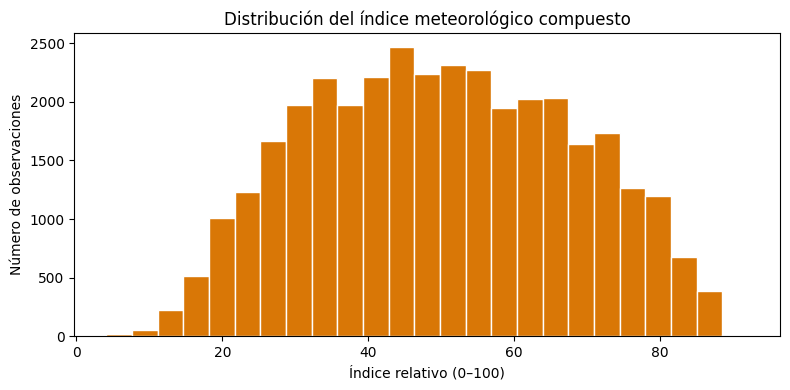

,observaciones,indice_medio,indice_mediano
ccaa,,,
Islas Baleares,223,62.327521,62.483633
Extremadura,4053,59.395475,56.965055
Andalucía,5032,59.371428,60.879790
Castilla-La Mancha,2594,59.130165,60.784421
Comunidad Valenciana,2478,57.205628,59.480218
Región de Murcia,830,56.925794,60.154532
Canarias,2875,54.974741,57.747138
Madrid,565,52.804943,53.832899
Aragón,1451,51.524836,49.891736


CSV enriquecido guardado en: C:\Users\gonza\Desktop\wildfires-project-development\data\processed\enriched\firms_spain_final_con_indice.csv


In [3]:
display(df['indice_meteorologico'].describe(percentiles=[.1, .25, .5, .75, .9]).to_frame())
ax = df['indice_meteorologico'].dropna().plot(kind='hist', bins=25, figsize=(8, 4), color='#d97706', edgecolor='white')
ax.set(title='Distribución del índice meteorológico compuesto', xlabel='Índice relativo (0–100)', ylabel='Número de observaciones')
plt.tight_layout()
plt.show()

if 'ccaa' in df.columns:
    resumen_ccaa = (df.groupby('ccaa', dropna=False)
                    .agg(observaciones=('indice_meteorologico', 'count'),
                         indice_medio=('indice_meteorologico', 'mean'),
                         indice_mediano=('indice_meteorologico', 'median'))
                    .sort_values('indice_medio', ascending=False))
    display(resumen_ccaa)

output_path = csv_path.with_name('firms_spain_final_con_indice.csv')
df.to_csv(output_path, index=False)
print(f'CSV enriquecido guardado en: {output_path}')